# Retail Sales Performance & Customer Segmentation Analysis

**Goal:** Identify where the business is losing profit margin and which customers marketing should prioritize.

**Dataset:** 2 years (2023–2024) of retail order-line data across 4 regions, 3 categories, and 500 customers, exported in a realistically messy format (mixed date formats, missing values, duplicates, sign errors).

**Workflow:**
1. Data Cleaning
2. SQL Analysis (KPIs, regional/category performance, discount impact)
3. RFM Customer Segmentation
4. Visualization
5. Business Recommendations


## 1. Setup

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from IPython.display import Image, display

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


## 2. Data Cleaning

The raw export (`data/raw/sales_data_raw.csv`) contains:
- Mixed date formats (`YYYY-MM-DD`, `MM/DD/YYYY`, `DD-Mon-YYYY`)
- ~70 duplicate rows from a double export
- Missing values in `ship_mode`, `customer_name`, `discount`, `profit`
- Inconsistent text casing (`EAST` vs `East`) and stray whitespace
- A handful of negative quantities (data entry sign errors)

Full logic lives in `scripts/clean_data.py`. Key decisions:
- **Dates** parsed with pandas' mixed-format parser rather than dropped.
- **Missing discount** assumed to mean no discount was applied (0%).
- **Missing profit** imputed using the category's median profit margin rather than deleting the row (deleting would bias category totals downward).
- **Missing customer_name** recovered via `customer_id` lookup where another row for that customer exists.
- **Negative quantities** corrected to absolute value (clear sign-entry error, not a return in this dataset).


In [2]:
raw = pd.read_csv("../data/raw/sales_data_raw.csv")
print("Raw shape:", raw.shape)
print("\nMissing values:\n", raw.isna().sum()[raw.isna().sum() > 0])


Raw shape: (9090, 16)

Missing values:
 ship_mode        135
customer_name     90
discount         181
profit            90
dtype: int64


In [3]:
df = pd.read_csv("../data/cleaned/sales_data_cleaned.csv", parse_dates=["order_date", "ship_date"])
print("Cleaned shape:", df.shape)
print("Remaining missing values:", df.isna().sum().sum())
df.head()


Cleaned shape: (9020, 20)
Remaining missing values: 0


,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,region,state,category,sub_category,quantity,unit_price,discount,sales,profit,order_year,order_month,days_to_ship,profit_margin
0,ORD-007376,2023-01-01,2023-01-07,Standard Class,CUST-0436,Sophia Johnson,Consumer,Central,Illinois,Office Supplies,Art,8,47.21,0.00,377.68,49.98,2023,2023-01,6,0.13
1,ORD-002406,2023-01-01,2023-01-05,Same Day,CUST-0399,Ashley Hicks,Home Office,Central,Michigan,Technology,Machines,6,490.78,0.00,"2,944.67",-234.65,2023,2023-01,4,-0.08
2,ORD-001069,2023-01-01,2023-01-02,First Class,CUST-0003,Angie Henderson,Home Office,East,New York,Technology,Accessories,8,412.22,0.00,"3,297.78","1,107.67",2023,2023-01,1,0.34
3,ORD-001937,2023-01-01,2023-01-02,First Class,CUST-0032,James Ferrell,Home Office,West,Oregon,Technology,Machines,5,268.32,0.20,"1,073.26",-190.21,2023,2023-01,1,-0.18
4,ORD-008787,2023-01-01,2023-01-07,Standard Class,CUST-0470,Jeanette Harrison,Corporate,South,Florida,Furniture,Furnishings,7,236.07,0.00,"1,652.49",27.21,2023,2023-01,6,0.02


## 3. SQL Analysis

Loading the cleaned data into SQLite and running the queries from `sql/analysis_queries.sql`.

In [4]:
conn = sqlite3.connect(":memory:")
df.to_sql("sales", conn, index=False)

kpi = pd.read_sql_query('''
    SELECT ROUND(SUM(sales),2) AS total_sales,
           ROUND(SUM(profit),2) AS total_profit,
           ROUND(SUM(profit)*100.0/SUM(sales),2) AS margin_pct,
           COUNT(DISTINCT order_id) AS total_orders,
           COUNT(DISTINCT customer_id) AS total_customers
    FROM sales
''', conn)
kpi


,total_sales,total_profit,margin_pct,total_orders,total_customers
0,"8,448,338.09","967,854.51",11.46,9000,500


### Regional performance

In [5]:
regional = pd.read_sql_query('''
    SELECT region,
           ROUND(SUM(sales),2) AS total_sales,
           ROUND(SUM(profit),2) AS total_profit,
           ROUND(SUM(profit)*100.0/SUM(sales),2) AS margin_pct
    FROM sales GROUP BY region ORDER BY total_sales DESC
''', conn)
regional


,region,total_sales,total_profit,margin_pct
0,East,"2,284,103.66","251,222.52",11.00
1,Central,"2,155,688.34","255,271.28",11.84
2,South,"2,092,830.08","239,361.96",11.44
3,West,"1,915,716.01","221,998.75",11.59


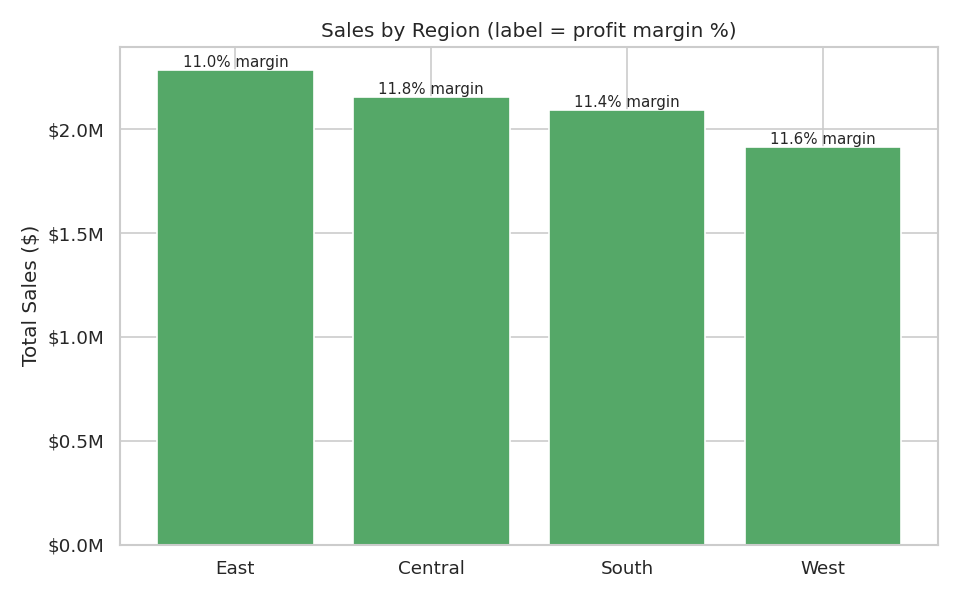

In [6]:
display(Image(filename="../visuals/02_regional_performance.png"))

### Discount impact on margin — the key finding

This is the most actionable insight in the dataset.

In [7]:
discount_impact = pd.read_sql_query('''
    SELECT
        CASE WHEN discount = 0 THEN '0% (no discount)'
             WHEN discount <= 0.15 THEN '1-15%'
             WHEN discount <= 0.25 THEN '16-25%'
             ELSE '26%+' END AS discount_band,
        ROUND(AVG(profit_margin)*100,2) AS avg_margin_pct,
        ROUND(SUM(sales),2) AS total_sales,
        COUNT(*) AS order_lines
    FROM sales GROUP BY discount_band ORDER BY discount_band
''', conn)
discount_impact


,discount_band,avg_margin_pct,total_sales,order_lines
0,0% (no discount),14.83,"4,243,297.79",4070
1,1-15%,15.14,"2,272,290.69",2472
2,16-25%,0.27,"1,006,884.98",1228
3,26%+,0.25,"925,864.63",1250


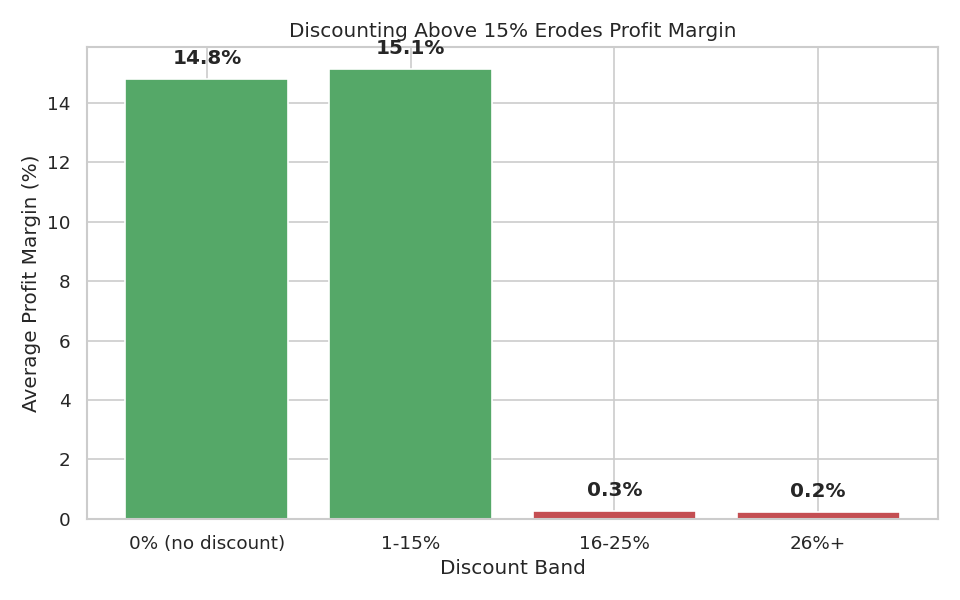

In [8]:
display(Image(filename="../visuals/03_discount_vs_margin.png"))

> **Finding:** Order lines discounted 15% or less retain a healthy ~15% average margin. The moment discount crosses the 16% threshold, average margin collapses to under 0.3% — those sales are essentially break-even or margin-losing once discount stacks with normal cost variance. Roughly [1228 + 1250] ≈ 2,478 order lines (~27% of all order lines) fall into this high-discount, near-zero-margin band.

### Category / sub-category breakdown

In [9]:
cat = pd.read_sql_query('''
    SELECT category, sub_category,
           ROUND(SUM(sales),2) AS total_sales,
           ROUND(SUM(profit),2) AS total_profit,
           ROUND(SUM(profit)*100.0/SUM(sales),2) AS margin_pct
    FROM sales GROUP BY category, sub_category ORDER BY total_sales DESC
''', conn)
cat


,category,sub_category,total_sales,total_profit,margin_pct
0,Technology,Machines,"1,300,957.47","143,528.09",11.03
1,Technology,Copiers,"1,226,520.35","136,188.72",11.10
2,Technology,Phones,"1,226,045.69","134,633.45",10.98
3,Technology,Accessories,"1,222,945.27","150,792.23",12.33
4,Furniture,Furnishings,"778,121.10","96,370.26",12.38
5,Furniture,Tables,"773,886.66","86,365.95",11.16
6,Furniture,Chairs,"751,802.42","90,791.95",12.08
7,Furniture,Bookcases,"743,991.20","78,257.40",10.52
8,Office Supplies,Art,"89,164.92","10,733.17",12.04
9,Office Supplies,Labels,"85,871.23","10,667.60",12.42


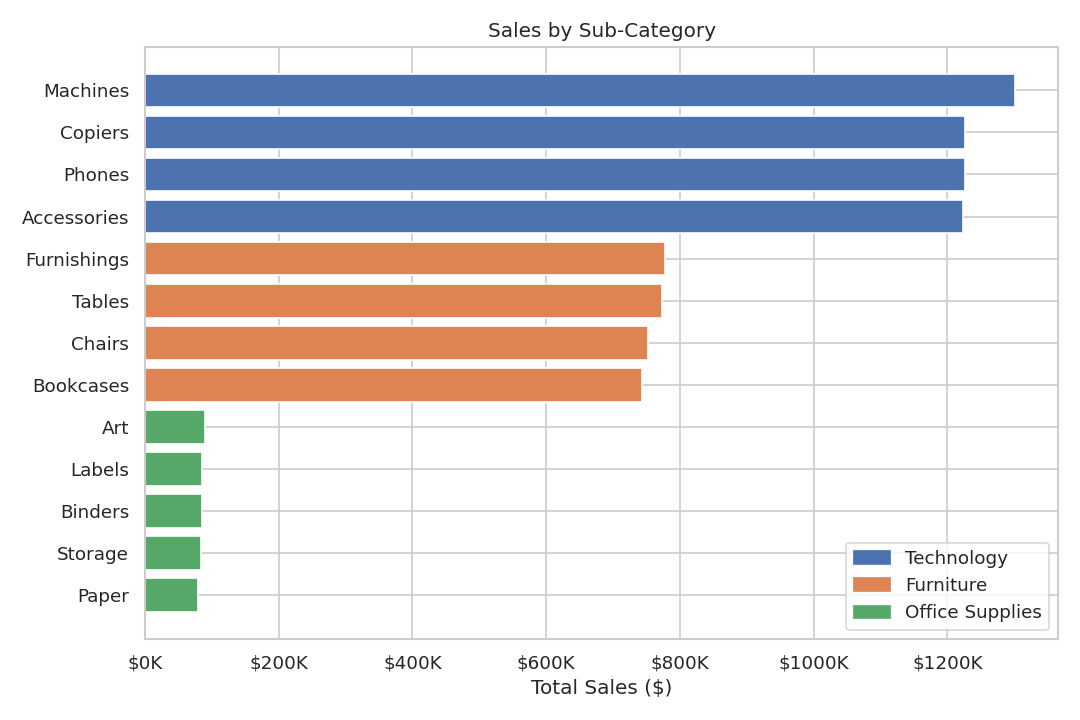

In [10]:
display(Image(filename="../visuals/04_subcategory_sales.png"))

### Monthly trend

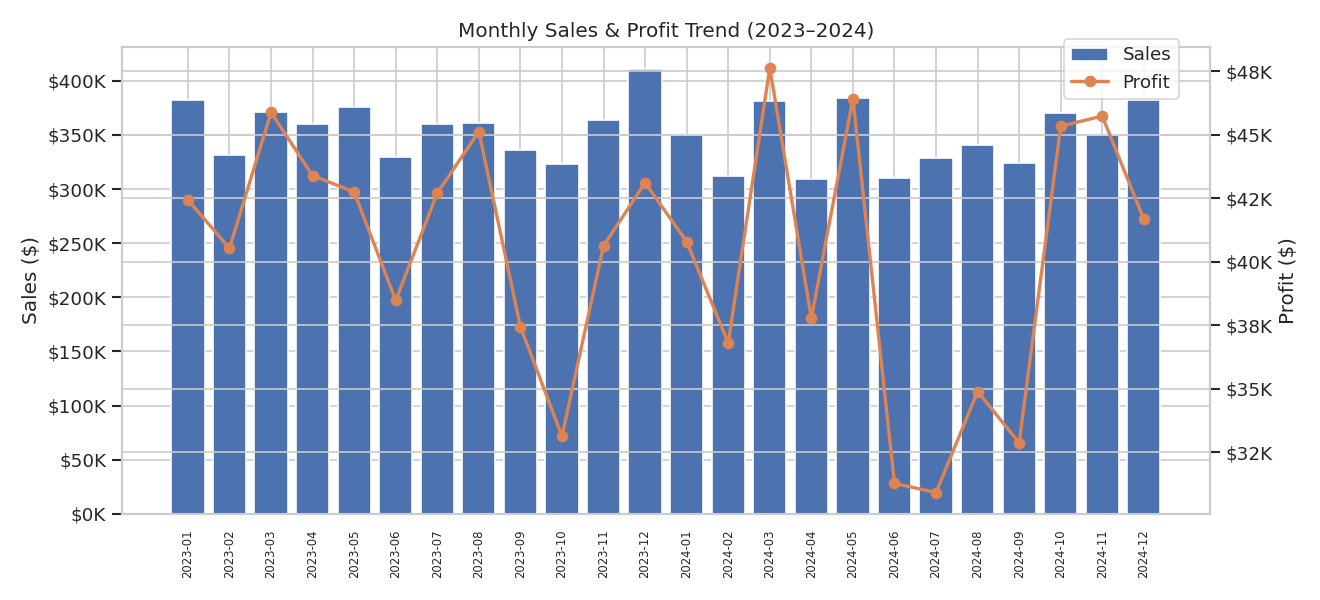

In [11]:
display(Image(filename="../visuals/01_monthly_sales_profit_trend.png"))

## 4. RFM Customer Segmentation

Recency, Frequency, and Monetary value are each scored 1–5 by quintile, then combined into
6 marketing-actionable segments (logic in `scripts/rfm_analysis.py`).

In [12]:
rfm = pd.read_csv("../data/cleaned/customer_rfm_segments.csv")
summary = rfm.groupby("segment").agg(
    customers=("customer_id", "count"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
).round(1).sort_values("avg_monetary", ascending=False)
summary


,customers,avg_recency,avg_frequency,avg_monetary
segment,,,,
Champions,70,10.70,22.50,"23,698.90"
At Risk,97,68.60,20.20,"19,244.00"
Loyal Customers,133,18.20,20.00,"17,596.60"
Needs Attention,62,55.60,14.50,"14,672.20"
New / Promising,70,11.10,14.10,"13,286.30"
Lost / Low Value,68,82.30,13.60,"10,921.80"


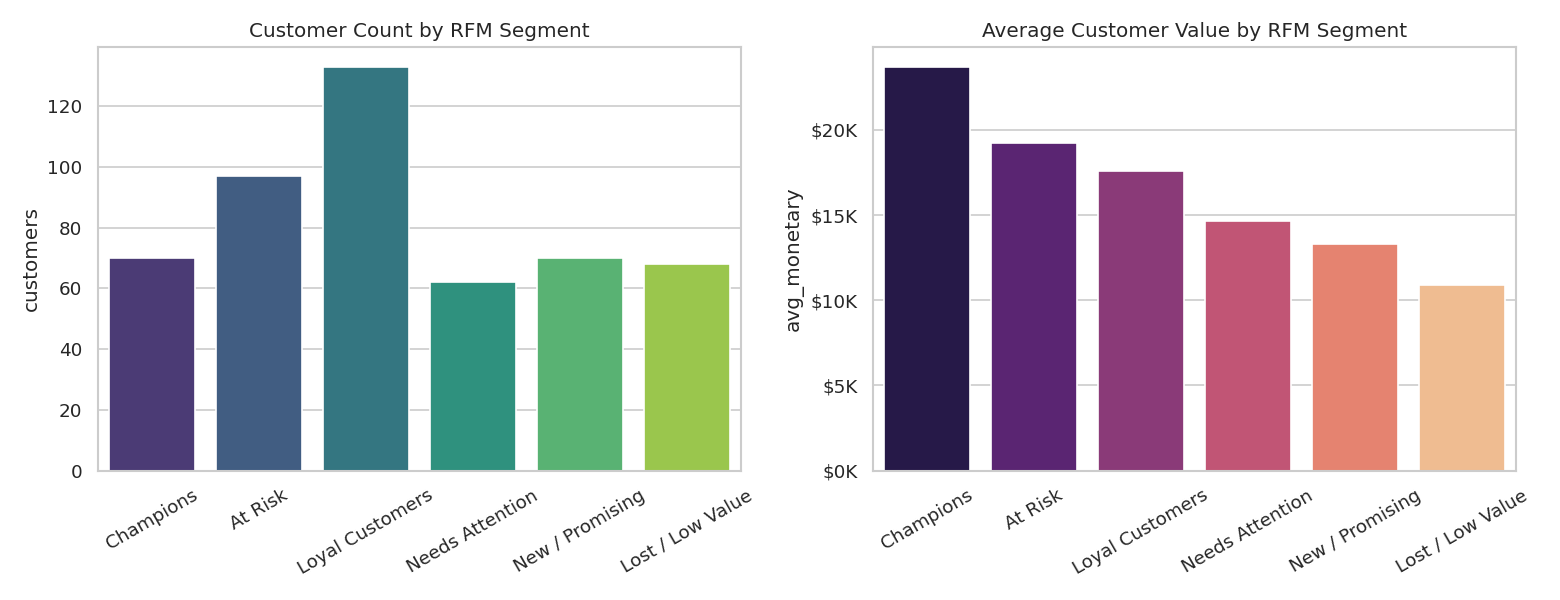

In [13]:
display(Image(filename="../visuals/05_rfm_segments.png"))

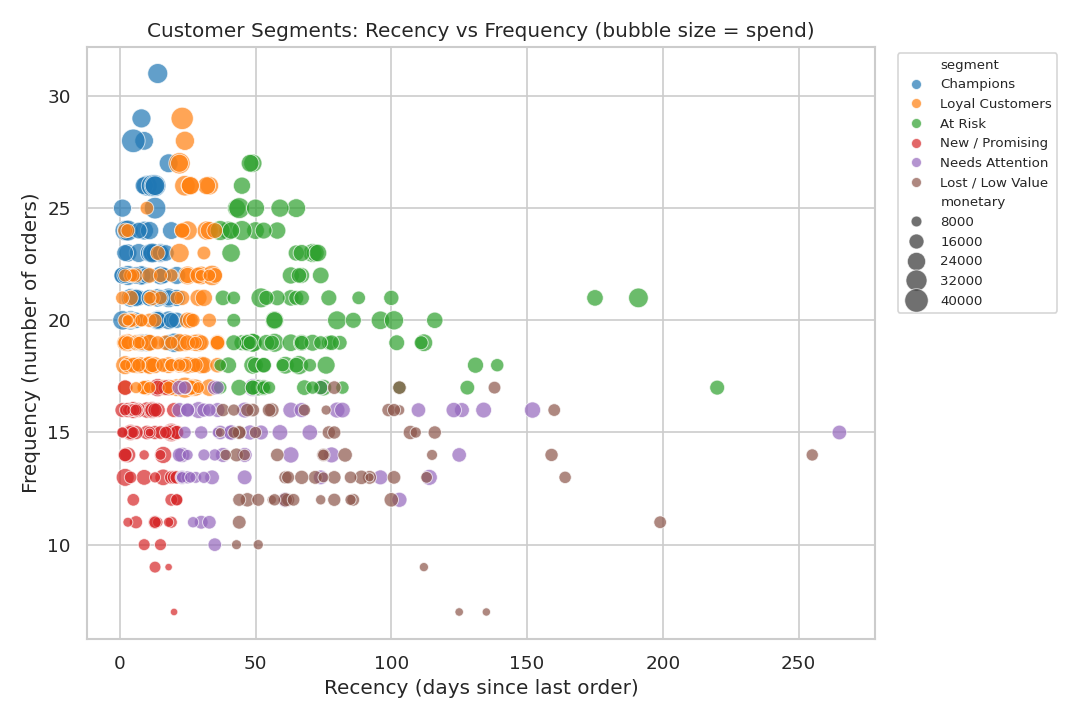

In [14]:
display(Image(filename="../visuals/06_rfm_scatter.png"))

> **Finding:** The **"At Risk"** segment (97 customers) has the *second-highest* average spend (~$19.2K) of any segment but hasn't ordered in 68+ days on average. This is high-value revenue actively churning — the single highest-leverage group for a win-back campaign.

## 5. Business Recommendations

1. **Cap standard discounting at 15%.** Margin drops from ~15% to ~0.3% once discounts exceed that threshold — discounts above 15% are effectively giving product away at cost. Route any deeper discount requests through a margin-approval step.
2. **Launch a win-back campaign for the "At Risk" segment.** These 97 customers represent an estimated $1.87M in historical spend and are trending toward churn (avg. 68 days since last order). A targeted offer or outreach here has a clear, quantifiable upside.
3. **Protect the Central region's margin advantage.** Central leads on margin % despite not leading on raw sales — worth understanding what's different operationally (e.g. lower shipping costs, different discount behavior) and replicating it elsewhere.
4. **Nurture "New / Promising" customers into "Loyal."** These 70 customers ordered recently but infrequently — an onboarding or second-purchase incentive could convert them before they lapse.
5. **Technology drives revenue but not proportionally more margin** — worth a pricing/cost review on Phones and Machines specifically, which post slightly lower margins than Accessories despite higher volume.
